## 분류 모델
- 분류: 범주를 예측하는 모델
- 종류
    - 이진 분류: 두 가지 범주로 분류할 수 있는 경우
                (상승/하락, 스팸 여부, 연체 여부 등)
    - 다중 분류: 여러 가지 범주로 분류할 수 있는 경우
                (섹터 예측, 신용 등급 등)
> **이진 분류**는 지표가 명확하여 가장 많이 사용되는 형태.

우리가 가지고 있는 데이터(시세)에서 `수익률`, `거래량_비율`, `이평대비`, `변동성`
데이터를 활용하여 상승(up)/하락(down)으로 분류 가능.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _style import setup
from _ml import build_dataset, time_split, FEATURES, SEED

# acuuracy_score (정확도), f1_score (정밀도, 재현율의 조화평균)
from sklearn.metrics import accuracy_score, f1_score

setup()
pd.set_option("display.width", 130)

df = build_dataset()
train, test, cutoff = time_split(df)

tr = train.sample(15_000, random_state=SEED)
te = test.sample(4_000, random_state=SEED)

X_train, y_train = tr[FEATURES], tr["target_up"]
X_test, y_test = te[FEATURES], te["target_up"]

print(f"* 학습 {len(tr):,}행 ({tr['date'].min().date()} ~ {tr['date'].max().date()})")
print(f"* 테스트 {len(te):,}행 ({te['date'].min().date()} ~ {te['date'].max().date()})")

* 학습 15,000행 (2023-10-24 ~ 2026-01-16)
* 테스트 4,000행 (2026-01-19 ~ 2026-09-07)


## 분류 알고리즘(모델) 종류 (대표적인 6가지)
모든 알고리즘은 동일한 방식으로 사용할 수 있음.

```python
model = 어떤모델()

model.fit(X_train, y_train)
pred = model.predict(X_test)
score = model.score(X_test, y_test)
```

- 종류
    - LogisticRegression (로지스틱 회귀)\
      : 선형 회귀 방식을 분류에 적용한 모델. 데이터가 어떤 범주에 속할 확률을 0과 1 사이의 값(확률)으로 예측.
        - 스케일링 필요. 빠른 속도.
        - 결과 해석이 쉽지만 성능은 보통 수준.
    - DecisionTree (의사결정나무)\
      : 스무고개 하듯이 데이터의 특징을 기준으로 질문을 던져가며 데이터를 분류하는 직관적인 트리 구조의 모델.
        - 스케일링 불필요. 빠른 속도.
        - 모델 해석이 쉬운 편이나, 과적합 되기 쉬우므로 단일 모델로는 비교적 낮은 성능.
    - KNN (K-Nearest-Neighbors, K-최근접 이웃)\
      : 새로운 데이터를 예측할 때, 주변에 가장 가까이 있는 K개의 이웃 데이터들이 속한 범주를 다수결로 판별하는 방식. 즉, K개의 이웃들 중 가장 많은 이웃 데이터가 속한 범주로 보냄.
        - 거리 기반이므로 스케일링 필수.
        - 학습은 없으나 예측 속도가 느림.
        - 제한적인 해석만 가능하고, 성능은 보통 수준.
    - RandomForest (랜덤 포레스트)\
      : 여러 개의 의사결정나무를 만들고, 이들의 예측 결과를 취합(투표나 평균)하여 최종 결과를 도출하는 앙상블 기법. (앙상블 기법: 여러 개의 개별 모델을 조화롭게 묶어 더 정확하고 뛰어난 단일 예측 결과를 도출하는 기법(방법론).)
        - 스케일링 불필요. 보통의 속도.
        - 트리가 여러 개이므로 단일 트리에 비해 해석은 제한적이나, 성능이 매우 뛰어나고 안정적.
    - SVM (Support Vector Machine)\
      : 클래스들을 구분하는 최적의 경계선을 찾는 알고리즘. 경계에서 가장 가까운 데이터와의 마진을 최대화함.
        - 스케일링 필요. 매우 느린 학습/예측 속도.
        - 내부가 블랙박스 같아 모델 해석이 어려우나, 데이터에 따라서는 매우 뛰어난 성능을 발휘하기도 함.
    - GradientBoosting (그래디언트 부스팅)\
      : 이전 트리가 만든 예측의 오차를 다음 트리가 보완하는 방식으로, 여러 개의 트리를 순차 학습시키는 앙상블 기법.
        - 스케일링 불필요. 트리를 순차적으로 만들기 때문에 느린 속도. (앞의 트리가 끝나야 다음 트리 생성 가능.)
        - 해석은 제한적이나, 머신러닝 알고리즘 중 비교적 높은 수준의 성능.

In [2]:
# 모델별로 성능 비교

# 다른 모델 성능을 비교할 기준선 생성용 분류기
from sklearn.dummy import DummyClassifier

# 앙상블 모델. 여러 개의 알고리즘이 합쳐진 모델.
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 선형 모델
from sklearn.linear_model import LogisticRegression
# KNN 모델
from sklearn.neighbors import KNeighborsClassifier
# 의사결정나무
from sklearn.tree import DecisionTreeClassifier
# SVM 모델
from sklearn.svm import SVC

# 각 피처의 평균을 0, 표준편차를 1로 맞춰주는 StandardScaler
from sklearn.preprocessing import StandardScaler
# 전체 과정(전처리 ~ 모델 학습)을 묶기 위한 도구
from sklearn.pipeline import Pipeline

# 스케일링이 필요한 모델은 Pipeline으로 묶어서 관리
def with_scaler(model):
    return Pipeline(
        [   # (단계, 이 단계에 사용할 객체)
            ("sc", StandardScaler()),
            ("m", model)
        ]
    )

# SVM => 속도가 pow(데이터 수, 2)에 비례하여 느려짐. 표본을 줄여서 사용.
SVM_N = 3_000

# "모델": (객체, 샘플링_여부) 구조
# 샘플링 여부: 표본 수 변경 여부. True가 변경, False는 변경 안 함.
models = {
    "DummyClassifier": (DummyClassifier(strategy="most_frequent"), False),
    # 표본 수 변경 없음. max_iter: 학습을 반복할 최대 횟수 설정
    "LogisticRegression": (with_scaler(
                            LogisticRegression(max_iter=1_000, 
                                               random_state=SEED)), False),
    # False: 표본 수 변경 없음
    "DecisionTree(제한없음)": (DecisionTreeClassifier(random_state=SEED), False),
    # 최대 트리 깊이 5 제한. 제한이 없으면 결과가 나올 때까지 계속 트리가 깊어짐.
    "DecisionTree(제한있음)": (DecisionTreeClassifier(max_depth=5, 
                                                      random_state=SEED), False),
    "KNN(k=50)": (with_scaler(KNeighborsClassifier(n_neighbors=50, n_jobs=-1)), False),
    "RandomForest": (RandomForestClassifier(n_estimators=100, max_depth=6, 
                                            random_state=SEED, n_jobs= -1), False),
    "GradientBoosting": (GradientBoostingClassifier(n_estimators=100, max_depth=3, 
                                                    random_state=SEED), False),
    "SVM (표본의 크기 3000)": (with_scaler(SVC(random_state=SEED)), True)
}

# 결과(row)를 담을 빈 list
# -> {"모델": 모델명, "학습": score, "테스트": score, "f1": f1, "학습시간": 시간} 형태
rows = []
for name, (model, small) in models.items():
    # small 값에 따라 표본 수 줄이기 (0 ~ 3_000행 슬라이싱)
    Xtr = X_train.iloc[:SVM_N] if small else X_train
    ytr = y_train.iloc[:SVM_N] if small else y_train

    t0 = time.perf_counter()
    model.fit(Xtr, ytr)
    # 모델별 학습시간 기록
    fit_time = time.perf_counter() - t0

    pred = model.predict(X_test)

    rows.append({
        "모델": name,
        # 이 model.score가 DummyClassifier보다 낮으면?
        # => 제대로 학습하지 못했다고 판단할 수 있다.
        "학습": model.score(Xtr, ytr),
        # model.score() 값과 accuracy_score() 값의 차이가 크면?
        # => 과적합이라고 판단 가능.
        "테스트": accuracy_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "학습시간": fit_time
    })

result = pd.DataFrame(rows)
print(result.round(4).to_string(index=False))

                모델     학습    테스트     F1   학습시간
   DummyClassifier 0.5069 0.5175 0.0000 0.0131
LogisticRegression 0.5107 0.4805 0.3859 0.0124
DecisionTree(제한없음) 1.0000 0.5005 0.4893 0.1325
DecisionTree(제한있음) 0.5219 0.4810 0.5245 0.0343
         KNN(k=50) 0.5672 0.5178 0.4708 0.0111
      RandomForest 0.6105 0.4932 0.4269 0.1603
  GradientBoosting 0.5987 0.4960 0.4434 2.0652
 SVM (표본의 크기 3000) 0.5720 0.4915 0.3787 0.1323


> DecisionTree(제한없음)의 model.score()값이 1로 나타나는데, 이건 답지를 외운 것으로 볼 수 있다. 특히, 테스트 점수(accuracy_score()값)와 학습 점수(model.score()값)의 차이가 거의 1/2이므로 과적합에 해당한다.

## 분류 모델 성능 결과

- **기준 모델: DummyClassifier**
    - 항상 다수 클래스로만 예측하는 모델. 이 모델의 테스트 정확도(0.5175)가 성능 평가의 최소 기준선이 된다.
    - 다른 머신러닝 모델의 정확도가 이보다 낮다면, 해당 모델은 의미 있는 패턴을 찾지 못하고 있는 것으로 해석할 수 있다. => 더 많은 데이터를 전달해보거나, 피처를 수정하는 등의 처리가 필요함.

- **정확도(Accuracy)와 F1 점수**
    - `Dummy`는 정확도가 높은 편이지만, 한 가지로만 분류했기 때문에 소수 클래스를 맞출 확률이 없어 F1 점수가 `0.0000`으로 나타난다.
    - 이에 반해, `DecisionTree(제한있음)`는 상대적으로 낮은 정확도를 보이지만 F1 점수가 **`0.5245`**로 가장 높다.
    - 불균형하거나 정제되지 않은 데이터에서는 정확도만 보고 판단하기보다, F1 점수 등 다른 지표를 함께 확인해야 한다.

- **트리의 과적합**
    - `DecisionTree(제한없음)`의 학습 정확도(`model.score()` 점수)가 `1.0000`로 나타나는 것은 학습 데이터를 100% 외웠다는 의미이다. 테스트 결과(`accuracy_score()` 점수)와의 격차가 거의 1/2에 달하여 가장 큰데, 이는 성능이 절반 수준으로 뚝 떨어진 것과 같고, 전형적인 과적합 상태에 해당한다. 제약(가지치기)의 필요성을 나타내는 것으로 해석할 수 있다.

- **알고리즘별 연산 비용(학습 시간)의 한계**
    - **GradientBoosting**: 학습 시간이 2초 이상. 앞의 트리가 만든 오차를 뒤의 트리가 순차적으로 고쳐나가야 하므로, 병렬 처리가 불가한 부스팅 알고리즘 특유의 느린 속도를 보여준다.
    - **SVM**: 표본의 크기(데이터 개수)를 전체의 20% 수준으로 줄였음에도 약 0.13초 소요. 표본의 크기 n에 대하여 n의 제곱 이상으로 연산량이 폭증하는 SVM의 단점을 확인할 수 있음.    

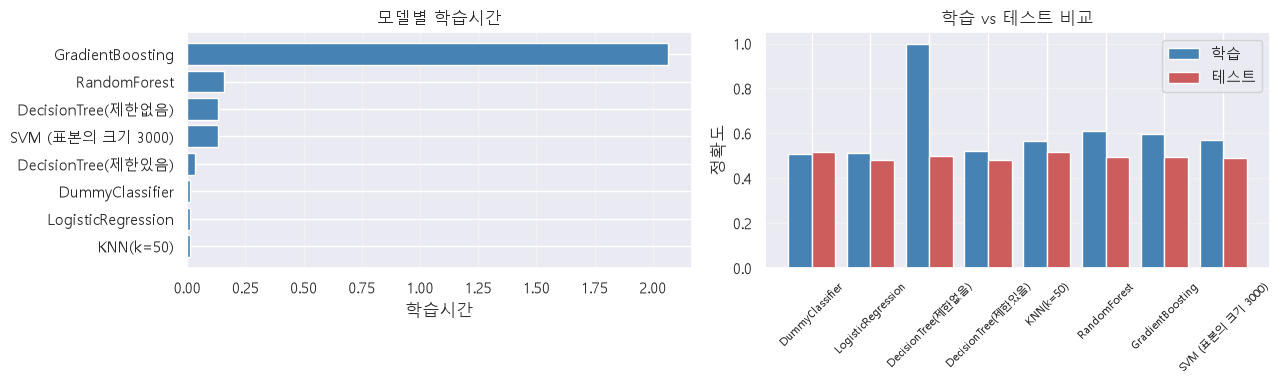

In [3]:
# 시각화하여 비교하기
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 학습 시간
r = result.sort_values("학습시간")

# barh(y축, x축): 가로 막대 그래프 (bar-horizontal)
axes[0].barh(r["모델"], r["학습시간"], color="steelblue")
axes[0].set_xlabel("학습시간")
axes[0].set_title("모델별 학습시간")
axes[0].grid(alpha=0.3, axis="x")

# 학습 vs 테스트 정확도 비교
x = np.arange(len(result))
# x: 가로축 위치 조정 (동일한 그래프를 겹치지 않게 표시하도록 설정)
# height: 막대 높이. 즉 표현할 데이터 값.
# width: 막대 너비(두께).
axes[1].bar(x=x - 0.2, width=0.4, height=result["학습"], 
            label="학습", color="steelblue")
axes[1].bar(x=x + 0.2, width=0.4, height=result["테스트"], 
            label="테스트", color="indianred")
# x축 눈금의 기본 위치
axes[1].set_xticks(x)
axes[1].set_xticklabels(result["모델"], rotation=45, fontsize=8)
axes[1].set_ylabel("정확도")
axes[1].set_title("학습 vs 테스트 비교")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

---

## KNN (K-Nearest Neighbors) - 가장 가까운 샘플 K개를 찾아 다수결로 결정

**핵심 원리**: "유유상종(끼리끼리 모인다)". 새로운 데이터가 들어오면, 거리가 가장 가까운 기존 데이터 K개를 찾아 그들이 가장 많이 속한 클래스로 예측함.

## K값에 따른 모델 제어 (과적합 조절)
- **k값이 너무 작을 때 (ex. k=1)**
    : 오직 가장 가까운 1개만 보고 판단하므로, 데이터의 사소한 노이즈(이상치)에도 민감하게 반응함. 경계선이 복잡해지고 **과적합** 발생.
- **k값이 너무 클 때**
    : 동네 사람 전체에게 물어보는 꼴이 되어, 무조건 다수 클래스로 예측해버리는 둔감한 모델이 됨. 단순해져서 **과소적합** 발생.
> **적절한 k값을 찾는 것이 이 모델 성능의 핵심**

|장점|단점|
|:--:|:--:|
|개념이 단순함|예측할 때마다 전체 거리를 계산해야 함|
|학습이 사실상 없음|예측 시 데이터가 많으면 느림|
|비선형 경계 처리|스케일링 필수|

> **KNN은 게으른 학습기 (`fit()` 단계에서 할 일을 `predict()` 시점까지 미룸)**\
> 보통의 머신러닝 모델은 `fit()` 단계에서 공식을 만들고 `predict()` 단계에서 빠르게 정답을 도출하지만, KNN은 반대.\
> `fit()`에서는 훈련 데이터를 저장만 하고, `predict()` 호출이 들어오면 그때 모든 데이터와의 거리를 계산하므로 시간이 오래 걸림.

In [4]:
# K값에 따른 학습, 테스트 성능 비교
ks = [1, 3, 5, 10, 15, 30, 50, 100, 200, 500]

rows = []

for k in ks:
    # n_jobs=-1: PC의 모든 일꾼(CPU 코어) 총동원. => 최대 속도로 처리
    knn = with_scaler(KNeighborsClassifier(n_neighbors=k, n_jobs=-1))

    knn.fit(X_train, y_train)

    tr_s = knn.score(X_train, y_train)
    te_s = knn.score(X_test, y_test)

    rows.append({"k": k, "학습": tr_s, "테스트": te_s, "차이": tr_s - te_s})

knn_result = pd.DataFrame(rows)
print(knn_result.round(4).to_string(index=False))

  k     학습    테스트     차이
  1 1.0000 0.5052 0.4948
  3 0.7562 0.4892 0.2669
  5 0.6916 0.4940 0.1976
 10 0.6273 0.5042 0.1230
 15 0.6115 0.5135 0.0980
 30 0.5845 0.5220 0.0625
 50 0.5672 0.5178 0.0494
100 0.5510 0.5110 0.0400
200 0.5334 0.4968 0.0366
500 0.5232 0.4938 0.0294


k=1일 때 학습점수 `1.0000`, 테스트()점수 `0.5052`로 성능 차이가 매우 큼. **과적합**\
k=500

## K값 변화에 따른 성능 비교
- **k=1일 때(너무 작은 k값): 극단적인 과적합**
    - 학습 정확도(`knn.score(X_train, y_train)`) : `1.0000`
        - 학습 데이터로 예측을 수행할 때, '자기 자신'이 가장 가까운 1개의 이웃이 되므로 무조건 정답을 맞히게 된다. (답안지를 보고 시험을 푸는 것과 동일함.)
    - 테스트 정확도(`knn.score(X_test, y_test)`): `0.5052`
        - 테스트 정확도는 매우 낮고 학습 정확도와의 차이도 가장 크다. 전형적인 과적합 상태에 해당.

- **k=500일 때(너무 큰 k값): 과소적합**
    - k값을 무작정 키우면 과하게 많은 데이터의 결과를 참고하게 된다.
    - 결국 데이터의 미세한 특징이 무시되어, 무조건 '가장 많은 다수 클래스'로만 예측하게 된다.

> **k=30일 때: `0.5220`으로 가장 높은 테스트 정확도**\
> 현재 데이터를 기준으로는 30 부근이 과적합과 과소적합 사이의 최적점임을 알 수 있다.

##### **KNN은 가장 가까운 거리를 구하는 것이므로 항상 `스케일링`이 필수!**

---

## 앙상블 (Ensemble)
"집단 지성". 단일 모델의 한계를 극복하기 위해 여러 모델의 의견을 모으는 방식.

|방식|결합 방법|대표 모델|
|:--:|:--:|:--:|
|보팅(Voting)|서로 다른 알고리즘을 결합|직접 만들어서 사용|
|배깅(Bagging)|**같은** 알고리즘을 데이터만 무작위로 다르게 추출하여 **병렬 학습**|RandomForest
|부스팅(Boosting)|모델을 **순차적으로** 학습시키며 선행 모델의 약점을 보완|GradientBoosting, XGBoost, LightGBM|

**배깅과 부스팅의 차이**
- 배깅(Bagging): 여러 모델이 **동시에 따로** 학습하고, 마지막에 다수결로 의견을 모으는 방식. 분산을 줄여 과적합을 막는 전략.
    - 분산(Variance): 모델이 너무 복잡해서 데이터의 작은 노이즈(변동)에도 몹시 민감하게 반응하여, 데이터가 조금만 바뀌어도 결과가 크게 흔들리는 상태. (예: 과적합)
    -  Bagging: Bootstrap + Aggregating의 합성어. Bootstrap(부트스트랩)은 통계학 용어로, 원본 데이터에서 복원추출을 통해 여러 개의 엇비슷한 샘플 데이터셋을 만들어내는 기법이고, Aggregating(추합/통합)은 부트스트램으로 만들어진 여러 데이터셋으로 각각의 모델을 학습시킨 뒤 그 결과를 하나로 모으고 합치는 과정을 뜻한다.
- 부스팅(Boosting): **선행 모델이 틀린 것을 후행 모델이 집중적으로** 파고들며 순차적으로 학습하는 방식. 편향을 줄여 성능을 높이는 전략.
    - 편향(bias): 모델이 너무 단순하여 데이터의 경향성을 제대로 파악하지 못하고 엉뚱한 방향으로 치우쳐 있는 상태. (예: 과소적합)

In [5]:
# 단일 트리, 배깅, 부스팅 비교

models = {
    "DecisionTree(단일트리)": DecisionTreeClassifier(max_depth=6, random_state=SEED),
    "RandomForest(배깅)":RandomForestClassifier(n_estimators=100,
                                                   max_depth=6, 
                                                   random_state=SEED, 
                                                   n_jobs=-1),
    "GradientBoosting(부스팅)": GradientBoostingClassifier(n_estimators=100,
                                                           max_depth=3,
                                                           random_state=SEED)
}

rows = []

for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    rows.append({
        "모델": name,
        "학습": model.score(X_train, y_train),
        "테스트": model.score(X_test, y_test),
        "학습시간": fit_time
    })

print(pd.DataFrame(rows).round(4).to_string(index=False))

                   모델     학습    테스트   학습시간
   DecisionTree(단일트리) 0.5279 0.4800 0.0422
     RandomForest(배깅) 0.6105 0.4932 0.1695
GradientBoosting(부스팅) 0.5987 0.4960 2.0570


**단일 트리보다 여러 개가 더 나은 이유**\
: 트리 하나는 특정 패턴에 치우칠 수 있다. 서로 다르게 치우친 트리 여러 개의 의견을 모으면 개별 오차를 줄일 수 있다.

**부스팅은 학습 시간이 더 긴 이유**\
: 배깅은 병렬 처리를 하지만 부스팅은 순차적으로 진행하므로 병렬화가 될 수 없다.